# `10_cecg_sqi_comparison.ipynb` — is the cECG quality index the right one?

The PAT004 window crystallised the problem: a near-perfect cECG (sharp, well-separated R-peaks, expert
correct at 0.00) scored only composite-SQI **0.74**, while morphology-clean-but-rhythm-useless PPG scored
0.90. The current composite is built from kurtosis (`kSQI`), skew (`sSQI`), band power (`pSQI`), detector
agreement (`bSQI`) and template correlation (`tSQI`) with fixed weights `(0.5, 0.3, 0.2)` — and several of
those measure *waveform shape*, not *whether the beats are cleanly detectable*, which is what actually
governs whether the cECG expert is right.

So we don't argue by eye. **An SQI's job in the fusion is to predict when its expert is trustworthy**, so we
rank candidate cECG indices by exactly that: how well each predicts **cECG-expert correctness** (single-
feature AUC + correlation), overall and on the hard bad-cECG subset. We test the existing components, four
new detectability-oriented indices, and a data-driven recombination — and let the numbers pick the index.

Self-contained; the new indices need raw cECG windows via `PatientSignals` (real data). A synthetic fallback
runs the whole thing so the logic is verifiable here.

## 1 · Setup + cECG expert + the correctness target

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks

os.chdir('/home/nik/projects/BA')

REPO_SRC, DATA_ROOT = "src/", "data/patients"
AF_LIST, RESULTS_DIR = "data/AF_patients.txt", "results/10"
FS, WINDOW_SEC, HOP_SEC, BCG_MODE, RANDOM_STATE = 128, 30, 15, "wavelet", 0
EXCLUDE_PATIENTS = []
WIN, HOP = WINDOW_SEC*FS, HOP_SEC*FS
BAD_Q = 0.10
os.makedirs(RESULTS_DIR, exist_ok=True); sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score

try:
    import extract as X
    from signal_loader import PatientSignals
    HAVE_REPO = True
except Exception as e:
    HAVE_REPO = False; print("repo src not importable ->", e)

CECG_COMPONENTS = ["kSQI", "sSQI", "pSQI", "bSQI", "tSQI", "composite"]

def synthetic(n_pat=40, win=40, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed); rows, groups, ys = [], [], []
    for pid in range(n_pat):
        for w in range(win):
            rows.append(f"PAT{pid:03d}"); groups.append(pid); ys.append(pid % 2)
    N=len(ys); yv=np.array(ys)
    base=rng.uniform(0,1,N); qual=np.clip(0.7*base+0.3*rng.uniform(0,1,N),0,1)
    data={"patient":rows,"win_idx":np.tile(np.arange(win),n_pat),
          "t_start_s":np.tile(np.arange(win)*HOP_SEC,n_pat),"AF":yv.astype(float),"y":yv.astype(float)}
    # existing cECG component SQIs (composite ~ quality; kSQI/tSQI noisier proxies)
    for k in CECG_COMPONENTS:
        noise = {"kSQI":0.4,"sSQI":0.5,"pSQI":0.3,"bSQI":0.2,"tSQI":0.45,"composite":0.12}[k]
        data[f"sqi_cecg_{k}"] = np.clip(qual + noise*rng.standard_normal(N), 0, 1)
    lab=pd.DataFrame(data); lab.attrs["_qual"]=qual
    return lab

if HAVE_REPO and os.path.exists(DATA_ROOT):
    cfg = X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS, window_s=WINDOW_SEC,
                          hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    lab = X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS: lab = lab[~lab["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    lab["y"]=lab["AF"].astype(float); lab=lab.dropna(subset=["y"]).reset_index(drop=True)
    CECG_FEAT = X.expert_feature_cols(lab, "cecg")
    SYNTHETIC=False; print("REAL data:", lab.shape)
else:
    print("!!! SYNTHETIC FALLBACK !!!"); lab=synthetic(); CECG_FEAT=[]; SYNTHETIC=True

y=lab["y"].astype(int).values; groups=lab["patient"].values

# cECG expert OOF prob + correctness target (what every candidate SQI must predict)
if not SYNTHETIC:
    Xm=lab[CECG_FEAT].to_numpy(float); p_cecg=np.full(len(lab),np.nan)
    for tr,te in LeaveOneGroupOut().split(Xm,y,groups):
        if len(np.unique(y[tr]))<2: p_cecg[te]=y[tr].mean(); continue
        clf=HistGradientBoostingClassifier(random_state=RANDOM_STATE)
        clf.fit(Xm[tr],y[tr],sample_weight=compute_sample_weight("balanced",y[tr]))
        p_cecg[te]=clf.predict_proba(Xm[te])[:,1]
else:
    rng=np.random.default_rng(1); q=lab.attrs["_qual"]
    p_cecg=np.clip(q*np.where(y==1,.85,.15)+(1-q)*rng.uniform(0,1,len(y)),1e-3,1-1e-3)

correct = ((p_cecg>=0.5).astype(int)==y).astype(int)
comp = np.nan_to_num(lab["sqi_cecg_composite"].to_numpy(float), nan=0.5)
badc = comp <= np.quantile(comp, BAD_Q)
print(f"cECG expert AUC={roc_auc_score(y,p_cecg):.3f} | correct windows={correct.mean():.2f} | bad-cECG n={int(badc.sum())}")


Cache gefunden -> lade results/10/features_sqi_cecg_cwt_b84841.csv
REAL data: (4724, 192)
cECG expert AUC=0.846 | correct windows=0.75 | bad-cECG n=473


## 2 · Scoring helper — does this SQI predict cECG-expert correctness?

For any candidate quality score `s` we report the **single-feature AUC** of `s` predicting `correct`
(0.5 = useless, higher = better quality signal), the Pearson correlation, and the same AUC restricted to the
**bad-cECG subset** (where it matters most). No training, no leakage — just "is this index monotone with the
expert being right?\"

In [2]:
def score_sqi(s, name):
    s = np.nan_to_num(np.asarray(s, float), nan=np.nanmedian(s) if np.isfinite(np.nanmedian(s)) else 0.0)
    def auc(mask):
        c = correct[mask]
        return roc_auc_score(c, s[mask]) if len(np.unique(c)) == 2 and np.std(s[mask]) > 1e-9 else np.nan
    corr = np.corrcoef(s, correct)[0, 1] if np.std(s) > 1e-9 else np.nan
    return dict(index=name, AUC_correctness=round(auc(np.ones(len(s), bool)), 3),
                corr=round(float(corr), 3) if np.isfinite(corr) else np.nan,
                AUC_on_badcECG=round(auc(badc), 3))
print("scoring helper ready — higher AUC_correctness = better quality index for cECG")


scoring helper ready — higher AUC_correctness = better quality index for cECG


## 3 · Tier 1 — the existing components (no raw signal needed)

Rank the SQIs you already have. This alone usually tells the story: morphology terms (`kSQI`/`sSQI`/`tSQI`)
weak, detector-agreement (`bSQI`) strong — and whether the fixed-weight `composite` is even the best
*combination* of its own parts.

In [3]:
tier1 = [score_sqi(lab[f"sqi_cecg_{k}"].to_numpy(float), k) for k in CECG_COMPONENTS]
df1 = pd.DataFrame(tier1).sort_values("AUC_correctness", ascending=False)
display(df1)
print("If kSQI/tSQI sit near 0.5 and bSQI is highest, the composite is down-weighting its best component.")


,index,AUC_correctness,corr,AUC_on_badcECG
4,tSQI,0.661,0.221,0.473
3,bSQI,0.633,0.158,0.432
5,composite,0.621,0.163,0.482
1,sSQI,0.578,0.070,0.452
2,pSQI,0.567,0.046,0.507
0,kSQI,0.465,0.025,0.653


If kSQI/tSQI sit near 0.5 and bSQI is highest, the composite is down-weighting its best component.


## 4 · Tier 2 — new detectability-oriented indices from the raw cECG

These target what actually makes a cECG window useful: are the R-peaks cleanly detectable and the beat
series physiologically sane? All are **AF-orthogonal** (a clean *AF* cECG still has detectable, physiologic
beats — we deliberately avoid RR-irregularity, which is the AF signal itself, not a quality measure).

- `rpeak_snr` — median R-peak prominence ÷ baseline noise.
- `rr_plausibility` — fraction of detected RR intervals in [0.3, 2.0] s.
- `spec_concentration` — peakiness of the PSD in the heart-rate band (is there one dominant rhythm?).
- `beat_count_ok` — is the implied mean HR in [30, 220] bpm?

In [4]:
def _peaks(w, fs):
    w = np.asarray(w, float)
    if w.size < 8 or not np.isfinite(w).all() or np.std(w) < 1e-9: return np.array([], int), w
    s = w - np.median(w); s = s if abs(s.max()) >= abs(s.min()) else -s     # orient to positive R-peaks
    pk, _ = find_peaks(s, distance=int(0.3*fs), prominence=np.std(s)*0.5)
    return pk, s
def rpeak_snr(w, fs):
    pk, s = _peaks(w, fs)
    if len(pk) < 3: return 0.0
    noise = np.median(np.abs(s - np.median(s))) + 1e-9
    return float(np.clip(np.median(s[pk]) / (noise*8), 0, 1))
def rr_plausibility(w, fs):
    pk, _ = _peaks(w, fs)
    if len(pk) < 4: return 0.0
    rr = np.diff(pk)/fs; return float(np.mean((rr >= 0.3) & (rr <= 2.0)))
def spec_concentration(w, fs, band=(0.7, 3.0)):
    w = np.asarray(w, float)
    if w.size < 8 or not np.isfinite(w).all() or np.std(w) < 1e-9: return 0.0
    f = np.fft.rfftfreq(len(w), 1/fs); psd = np.abs(np.fft.rfft(w - w.mean()))**2
    m = (f >= band[0]) & (f < band[1])
    return 0.0 if psd[m].sum() == 0 else float(np.clip(psd[m].max()/(psd[m].mean()+1e-12)/20, 0, 1))
def beat_count_ok(w, fs):
    pk, _ = _peaks(w, fs); hr = len(pk)/(len(w)/fs)*60; return float(30 <= hr <= 220)
NEW = {"rpeak_snr": rpeak_snr, "rr_plausibility": rr_plausibility,
       "spec_concentration": spec_concentration, "beat_count_ok": beat_count_ok}

# build candidate values per window (real: re-slice raw cECG; synthetic: generate)
def cecg_windows():
    """Yield (row_index, raw_cecg_window) for every labelled window."""
    if not SYNTHETIC:
        for pid, sub in lab.groupby("patient"):
            try:
                pat = PatientSignals(os.path.join(DATA_ROOT, pid)); pat.filter_all(fs=FS); pat.offset_correction(fs=FS)
                cec = pat.cecg_filt
                for idx, r in sub.iterrows():
                    s = int(round(r.t_start_s*FS)); yield idx, np.asarray(cec[s:s+WIN], float)
            except Exception as e:
                print(f"  {pid}: load error {e}")
                for idx in sub.index: yield idx, np.full(WIN, np.nan)
    else:
        rng = np.random.default_rng(7); q = lab.attrs["_qual"]
        for idx in lab.index:
            ww = np.zeros(WIN); hr = rng.uniform(0.9, 1.4)
            for L in np.arange(0.3, WINDOW_SEC, 1/hr):
                i = int(L*FS)
                if 4 <= i < WIN-4: ww[i-3:i+3] += q[idx]*np.array([.2,.6,1.,1.,.6,.2])
            ww += (1-q[idx])*rng.standard_normal(WIN)*0.5; yield idx, ww

newvals = {name: np.zeros(len(lab)) for name in NEW}
for idx, w in cecg_windows():
    for name, fn in NEW.items(): newvals[name][idx] = fn(w, FS)

tier2 = [score_sqi(newvals[name], name) for name in NEW]
df2 = pd.DataFrame(tier2).sort_values("AUC_correctness", ascending=False)
display(df2)


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False

,index,AUC_correctness,corr,AUC_on_badcECG
2,spec_concentration,0.572,0.140,0.361
0,rpeak_snr,0.528,0.050,0.559
3,beat_count_ok,0.500,0.001,0.407
1,rr_plausibility,0.491,0.003,0.419


## 5 · Full ranking + data-driven recombination

All candidates in one table, sorted by how well they predict cECG-expert correctness. Then the
**recalibration check**: a LOPO logistic regression of correctness on *all* candidate indices learns the
weights from data (replacing the hand-set `0.5/0.3/0.2`). If that `learned_cecg_quality` beats the current
composite's correctness-AUC, you have direct, leak-free evidence to swap the index.

,index,AUC_correctness,corr,AUC_on_badcECG
4,tSQI,0.661,0.221,0.473
3,bSQI,0.633,0.158,0.432
5,composite,0.621,0.163,0.482
1,sSQI,0.578,0.070,0.452
8,spec_concentration,0.572,0.140,0.361
2,pSQI,0.567,0.046,0.507
6,rpeak_snr,0.528,0.050,0.559
9,beat_count_ok,0.500,0.001,0.407
7,rr_plausibility,0.491,0.003,0.419
0,kSQI,0.465,0.025,0.653



current composite  -> correctness-AUC = 0.621
learned recombination (LOPO) -> correctness-AUC = 0.650  (BETTER)


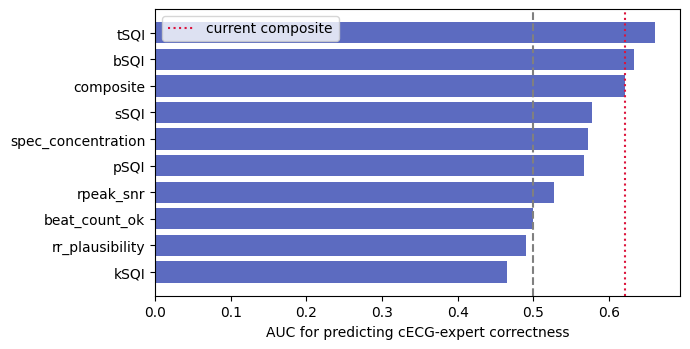

Best single index: tSQI  (AUC=0.661)


In [5]:
allvals = {k: lab[f"sqi_cecg_{k}"].to_numpy(float) for k in CECG_COMPONENTS}
allvals.update(newvals)
full = pd.DataFrame([score_sqi(v, k) for k, v in allvals.items()]).sort_values("AUC_correctness", ascending=False)
display(full)

# data-driven recombination (LOPO; no peeking)
M = np.column_stack([np.nan_to_num(v, nan=np.nanmedian(v)) for v in allvals.values()])
learned = np.full(len(lab), np.nan)
for tr, te in LeaveOneGroupOut().split(M, correct, groups):
    if len(np.unique(correct[tr])) < 2: learned[te] = correct[tr].mean(); continue
    lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(M[tr], correct[tr])
    learned[te] = lr.predict_proba(M[te])[:, 1]
auc_learned = roc_auc_score(correct, learned)
auc_comp = roc_auc_score(correct, np.nan_to_num(comp))
print(f"\ncurrent composite  -> correctness-AUC = {auc_comp:.3f}")
print(f"learned recombination (LOPO) -> correctness-AUC = {auc_learned:.3f}  "
      f"({'BETTER' if auc_learned>auc_comp+0.005 else 'no better'})")

best = full.iloc[0]
plt.figure(figsize=(7,3.6))
plt.barh(full["index"], full["AUC_correctness"], color="#5c6bc0")
plt.axvline(0.5, ls="--", c="grey"); plt.axvline(auc_comp, ls=":", c="crimson", label="current composite")
plt.xlabel("AUC for predicting cECG-expert correctness"); plt.legend(); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(f"Best single index: {best['index']}  (AUC={best['AUC_correctness']})")


## 5b · SEE IT — lowest vs highest-scoring real cECG window, per factor

The decisive test by eye. For every index we pull the window at its **5th percentile** (the index calls it
*bad*) and its **95th percentile** (*good*), and plot the raw cECG for both. Read each row: does the "good"
trace actually look like a clean, detectable QRS train and the "bad" one like flatline/noise/motion? If a
factor's good/bad panels look the *same* (or swapped), that factor is not measuring cECG quality and should
not drive the weight model — no matter what its AUC says. Each panel is annotated with the factor value, the
truth, and whether the cECG expert was right there.

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False

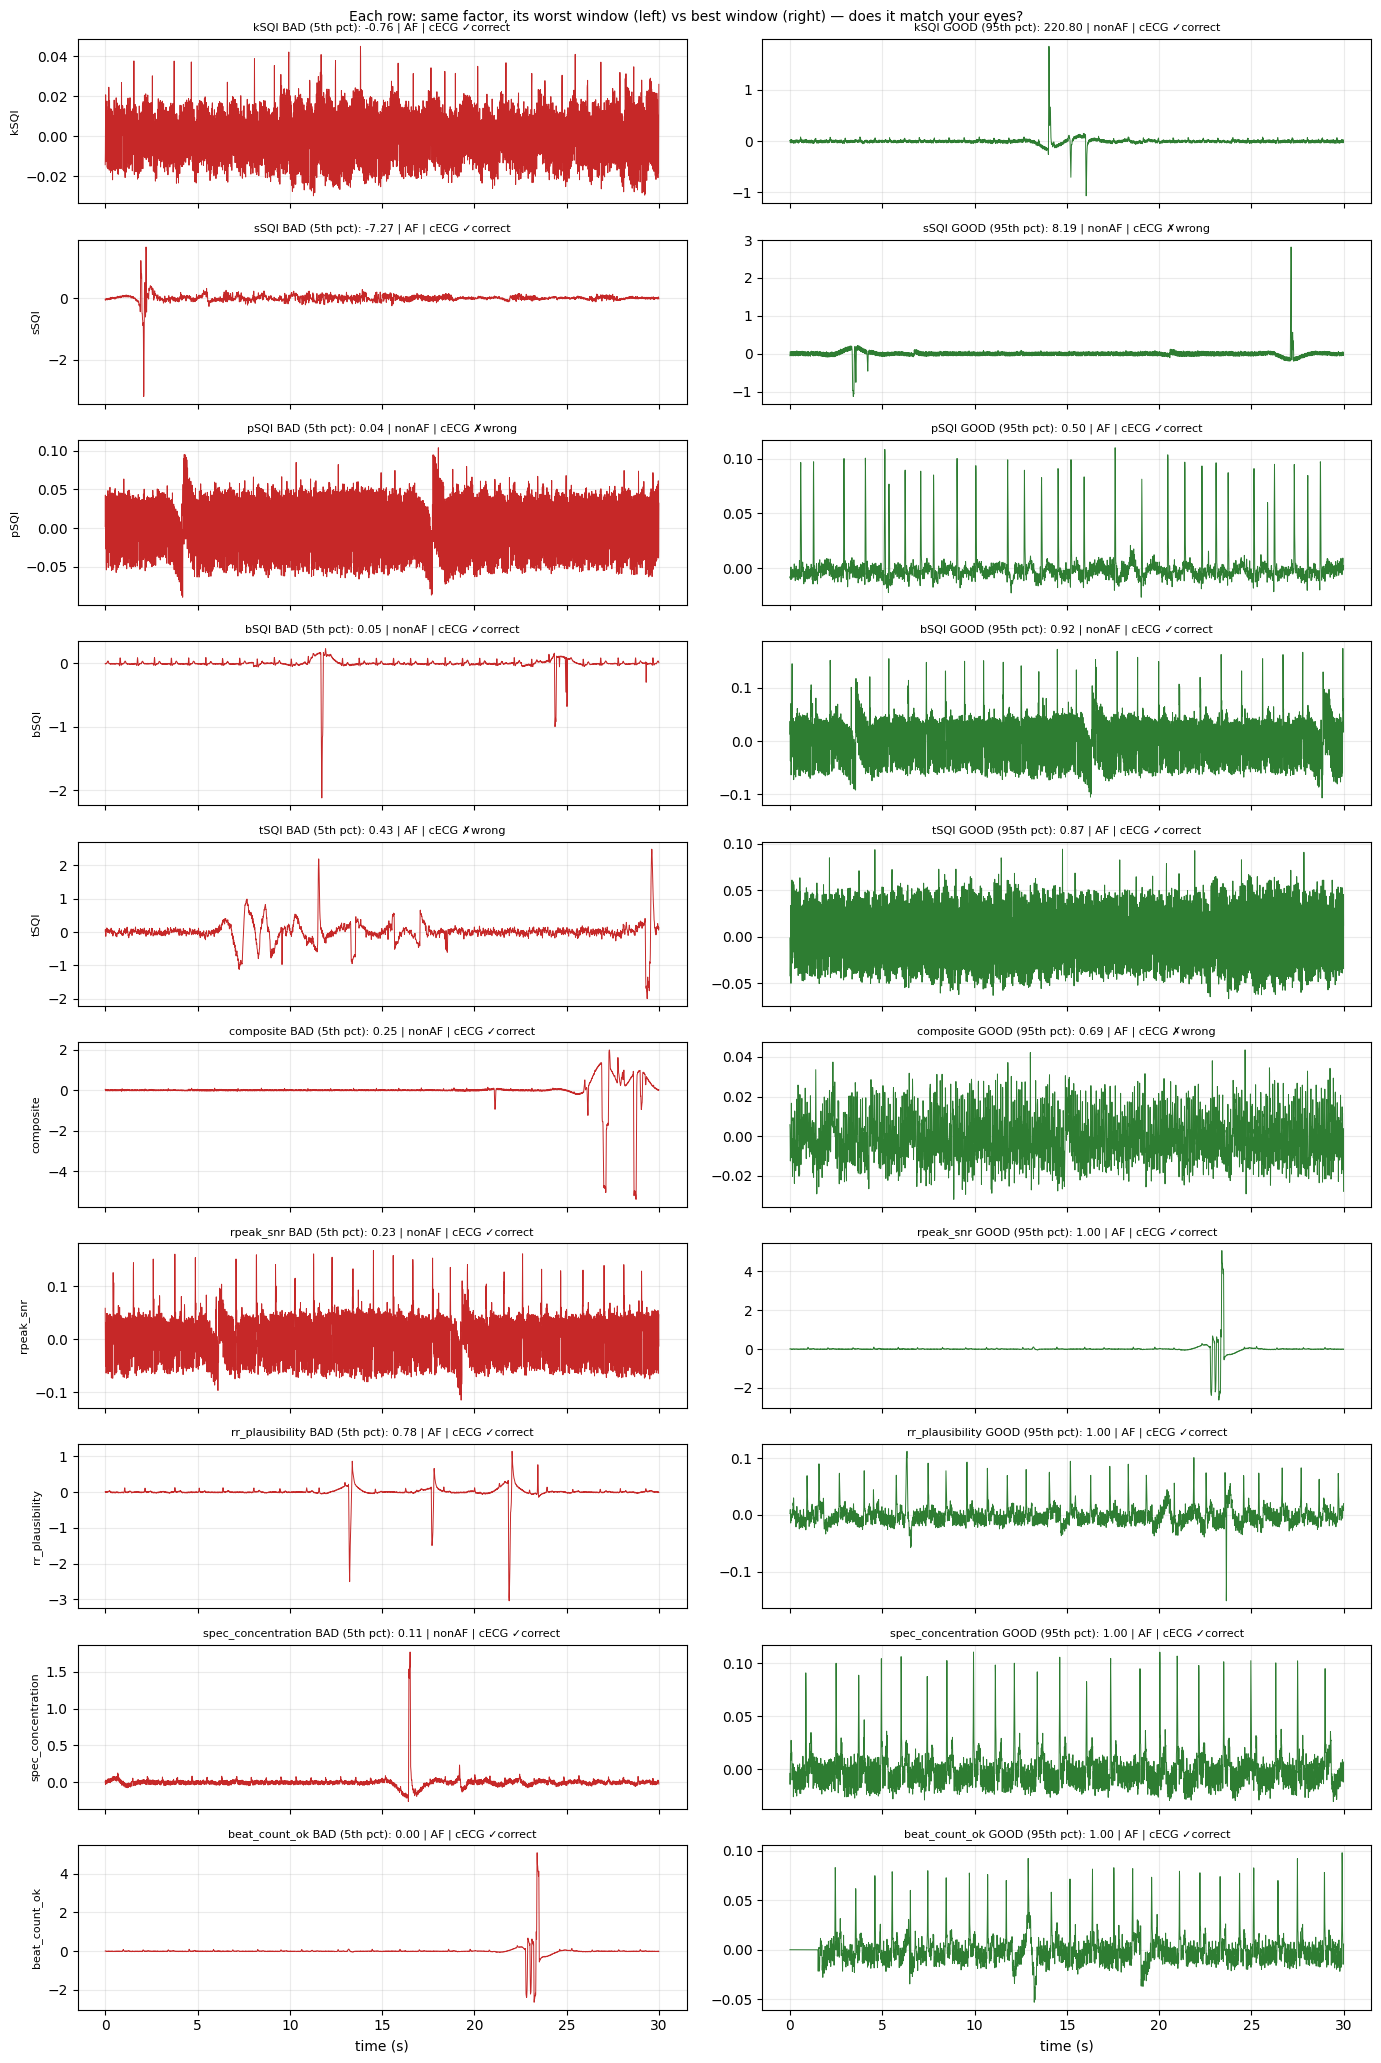

Verdict per factor (do it by eye):
 - good clean QRS on the right, noise/flatline on the left  -> the index MEASURES cECG quality (keep)
 - left and right look equally (un)clean, or swapped         -> the index is NOT cECG quality (drop)


In [6]:
FACTORS = allvals                      # 10 indices: 6 existing components + 4 new
LO_PCT, HI_PCT = 5, 95

# which windows do we need to show? (one bad + one good per factor)
def pick(vals, pct):
    v = np.asarray(vals, float); fin = np.isfinite(v)
    if fin.sum() == 0: return None
    target = np.percentile(v[fin], pct)
    cand = np.where(fin)[0]
    return int(cand[np.argmin(np.abs(v[cand] - target))])
picks = {name: (pick(v, LO_PCT), pick(v, HI_PCT)) for name, v in FACTORS.items()}
needed = {i for lohi in picks.values() for i in lohi if i is not None}

# fetch ONLY the needed raw windows (replays the generator once; exact same windows as Section 4)
CECG_RAW = {}
for idx, w in cecg_windows():
    if idx in needed: CECG_RAW[idx] = np.asarray(w, float)

t = np.arange(WIN) / FS
names = list(FACTORS.keys())
fig, axes = plt.subplots(len(names), 2, figsize=(14, 2.1*len(names)), sharex=True)
for row, name in enumerate(names):
    lo, hi = picks[name]
    for col, (idx, tag) in enumerate([(lo, "BAD (5th pct)"), (hi, "GOOD (95th pct)")]):
        ax = axes[row, col]
        if idx is None or idx not in CECG_RAW:
            ax.text(0.5, 0.5, "n/a", ha="center"); ax.set_axis_off(); continue
        ax.plot(t, CECG_RAW[idx], lw=.7, color=("#c62828" if col == 0 else "#2e7d32"))
        val = FACTORS[name][idx]; tru = "AF" if y[idx] == 1 else "nonAF"
        ok = "✓correct" if correct[idx] == 1 else "✗wrong"
        ax.set_title(f"{name} {tag}: {val:.2f} | {tru} | cECG {ok}", fontsize=8)
        ax.grid(alpha=.25)
    axes[row, 0].set_ylabel(name, fontsize=8)
axes[-1, 0].set_xlabel("time (s)"); axes[-1, 1].set_xlabel("time (s)")
fig.suptitle("Each row: same factor, its worst window (left) vs best window (right) — does it match your eyes?",
             fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.995]); plt.show()

print("Verdict per factor (do it by eye):")
print(" - good clean QRS on the right, noise/flatline on the left  -> the index MEASURES cECG quality (keep)")
print(" - left and right look equally (un)clean, or swapped         -> the index is NOT cECG quality (drop)")


## 6 · What to do with the result

- **If a detectability index (e.g. `rpeak_snr` / `bSQI` / `spec_concentration`) beats the composite**, that
  is your evidence the current kurtosis-driven composite is the wrong cECG quality index. Replace
  `composite_sqi`'s cECG weighting in `sqi.py` (or add the winner as a new `sqi_cecg_*` column and let
  `gate_sqi_cols` pick it up), then re-run the fusion/abstention notebooks with the better index driving the
  weight model.
- **If the learned recombination wins**, the components are fine but the fixed `(0.5,0.3,0.2)` weights are
  not — replace the hand weights with the learned ones (per-signal), which also directly answers "determine
  a *suitable* quality index" rather than a default one.
- **Either way you can now justify the choice with a number** (correctness-AUC), not an eyeball — exactly
  the rigour the algorithm-comparison brief expects, and it directly attacks the quality≠correctness gap.
- Repeat this harness per signal (PPG, BCG) — the right index is likely different per modality (PPG/BCG have
  no reliable R-peak, so `spec_concentration` / inter-channel agreement may win there instead of `rpeak_snr`).

> Caveat: rank by the **overall** correctness-AUC, not by one window. And keep the comparison LOPO-honest —
> the recombination above already is; if you tune any index's internal thresholds, wrap that in nested CV.